# EDA and Business Insights

Customer churn is a central challenge in the telecommunications industry, where subscription-based revenue models make retention a key driver of long-term profitability. Rather than treating churn as a purely descriptive outcome, this project approaches it as a decision problem: which customers are most at risk, what appears to drive that risk and which actions may realistically help reduce it.

Beyond prediction alone, the objective is to extract insights that are useful for decision-making. This means identifying the main patterns associated with churn, understanding how different customer profiles behave and highlighting the business levers that could plausibly support retention strategies.

This notebook focuses on exploratory data analysis. Its purpose is to build an initial understanding of customer behavior, validate key assumptions and assess data quality before moving to predictive modeling. Particular attention is given to contract structure, service usage and payment behavior, as these dimensions are likely to shape both churn risk and the operational reading of future model outputs.


## Imports

In [1]:
from pathlib import Path
import sys

import pandas as pd

In [2]:
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from src.telco_churn.visualization import (
    set_theme,
    bar_plot,
    stacked_bar,
    kde_plot,
)

from src.telco_churn.config import (
    FIGURES_DIR,
)

set_theme()

## 1. Data Exploration and Quality Checks

In [4]:
data_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(data_path)

We'll start by checking the dimensions of the dataset, identify potential duplicates and have a look at the first lines of the data.

In [5]:
print(f"Dataset shape: {df.shape}")
print(f"Number of duplicates: {df.duplicated().sum()}")

df.head()

Dataset shape: (7043, 21)
Number of duplicates: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Then, we must check variable types and detect any anomalies in the dataset.

In [6]:
# check data types
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


The `TotalCharges` column is expected to be numeric but is loaded as a string. Let's find the specific values that are preventing the conversion to find the root cause.

In [7]:
# Use regex to create a numeric check
is_numeric = df["TotalCharges"].str.match(r'^-?\d*\.?\d*$')

# Display the unique values failing the numeric check
non_numeric_values = df.loc[~is_numeric, "TotalCharges"].unique()
print(f"Non-numeric values found: {non_numeric_values}")

# Number of rows affected
anomalies_count = (~is_numeric).sum()
print(f"Number of problematic rows: {anomalies_count}")

Non-numeric values found: <StringArray>
[' ']
Length: 1, dtype: str
Number of problematic rows: 11


Given that the non-numeric values are only empty strings, we can safely convert it to numeric.

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = 'coerce')
print(f"New data type: {df["TotalCharges"].dtype}")

New data type: float64


We can now check the missing values in the dataset.

In [9]:
# Check for missing values in the entire dataset
df.isnull().sum()

# remove missing values
df = df.dropna()

The missing values are exclusively in the `TotalCharges` rows we just converted. Given their negligible volume, these rows are removed here to keep the exploratory analysis simple and based on a fully clean dataset.

We check the number of unique values for each categorical variable. High cardinality may indicate noisy data, requiring a specific encoding or removal.

In [10]:
# select object columns and count unique values
cardinality = df.select_dtypes(include=['object', 'string']).nunique().sort_values(ascending = False)
print("Unique values per categorical column:")
print(cardinality)

Unique values per categorical column:
customerID          7032
PaymentMethod          4
DeviceProtection       3
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
gender                 2
PhoneService           2
Dependents             2
PaperlessBilling       2
Partner                2
Churn                  2
dtype: int64


We examine the distribution of numerical variables to detect potential outliers or illogical values.

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## 2. The Attrition Landscape (Target Analysis)

Figure saved.


<Axes: title={'center': 'Distribution of Customer Churn'}>

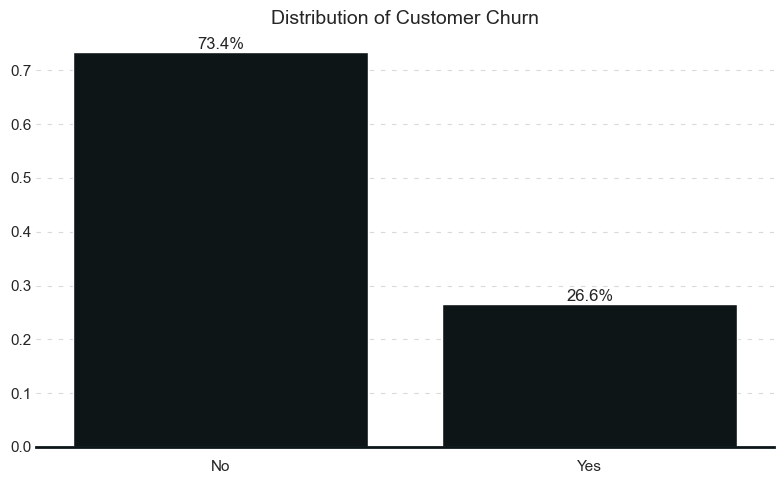

In [12]:
bar_plot(data=df, 
         column="Churn", 
         title="Distribution of Customer Churn", 
         normalize=True,
         save_path=FIGURES_DIR / "churn_distribution.png",
         )

Approximately 26.5% of customers have churned, representing a significant leakage in a subscription-based revenue model. Losing over a quarter of the customer base suggests that a substantial share of customers may leave before generating enough value to offset their acquisition cost, directly impacting long-term profitability.

From a modeling perspective, this imbalance requires adapting both evaluation metrics and training strategy. A naive model predicting "No churn" for all customers would still achieve high accuracy while providing no business value. Instead, the focus should be placed on metrics such as ROC-AUC, recall and F1-score, which better capture the model’s ability to identify at-risk customers.

This imbalance also has implications for model training, requiring appropriate sampling strategies and calibration to ensure that churn cases receive sufficient attention during learning.


## 3. Understanding Key Churn Drivers

### 3.1. The Onboarding Crisis: High Early-Stage Churn

Understanding when customers are most likely to leave is key to designing effective retention strategies. The `tenure` variable, representing how long a customer has stayed with the company, provides insight into high-risk periods in the customer lifecycle.

Figure saved.


<Axes: title={'center': 'Distribution of Tenure: Churn vs Retained Customers'}, xlabel='tenure', ylabel='Density'>

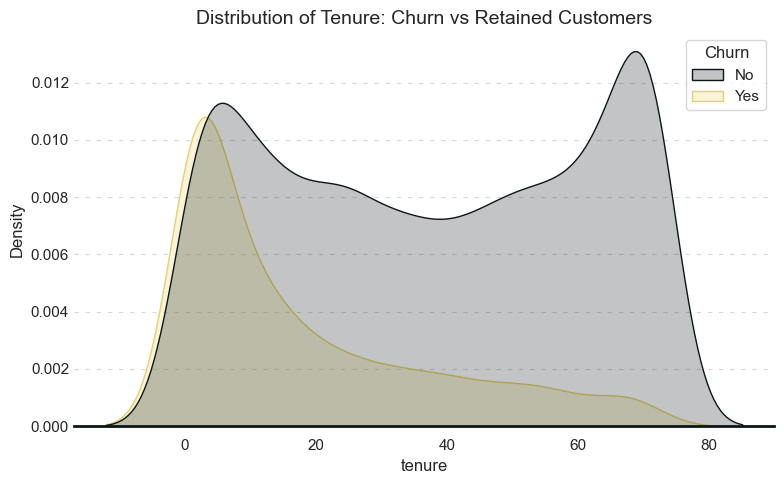

In [13]:
kde_plot(
    data=df,
    x="tenure",
    hue="Churn",
    title="Distribution of Tenure: Churn vs Retained Customers",
    save_path=FIGURES_DIR / "tenure_kde.png",
)

The distribution clearly shows that churn is significantly higher during the early months. This highlights a critical vulnerability in the onboarding phase, where customers have not yet developed strong attachment or perceived value.

From a business perspective, this suggests that retention efforts should be heavily concentrated in the first months of the customer journey. Interventions such as onboarding optimization, early engagement campaigns or targeted incentives could have a disproportionate impact by addressing churn at its most sensitive stage.


### 3.2. The Premium Risk: Fiber Optic as a Churn Catalyst

Before analyzing behavior, we must look at the financial stakes associated with each technology. The distribution of monthly charges shows a clear hierarchy in the company's revenue streams.

Figure saved.


<Axes: title={'center': 'Distribution of Monthly Charges: No Internet Service vs DSL vs Fiber Optic'}, xlabel='MonthlyCharges', ylabel='Density'>

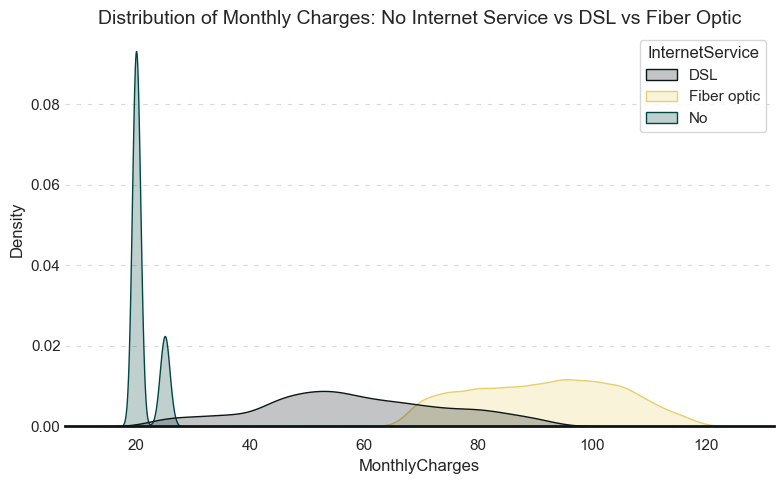

In [14]:
kde_plot(
    data=df,
    x="MonthlyCharges",
    hue="InternetService",
    title="Distribution of Monthly Charges: No Internet Service vs DSL vs Fiber Optic",
    save_path=FIGURES_DIR / "monthly_charges_kde.png",
)

This graph confirms that fiber optic customers represent the high-value segment of the database, with a pricing density peaking significantly higher than DSL or landline-only users. From a business perspective, these are the most profitable accounts. However, as we will see in the next section, this high-value segment is also the most vulnerable to attrition.

### 3.3 Behavioral Profiles: Digital Volatility vs Traditional Stability

Figure saved.
Figure saved.
Figure saved.


<Axes: title={'center': 'Payment Behavior'}, ylabel='Proportion'>

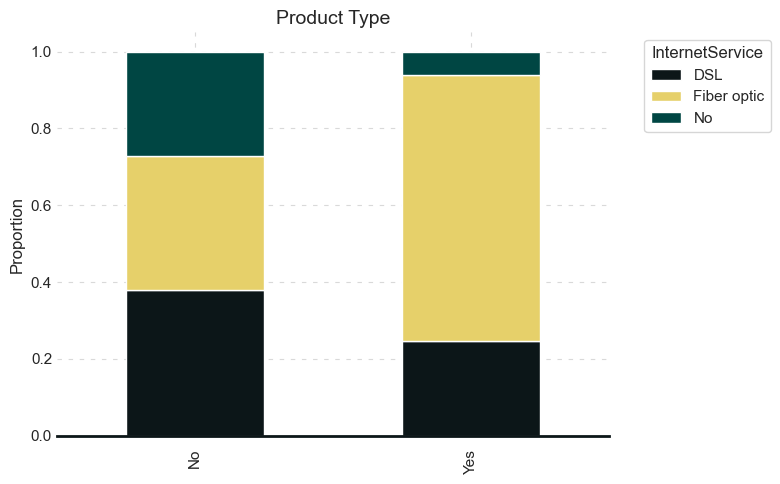

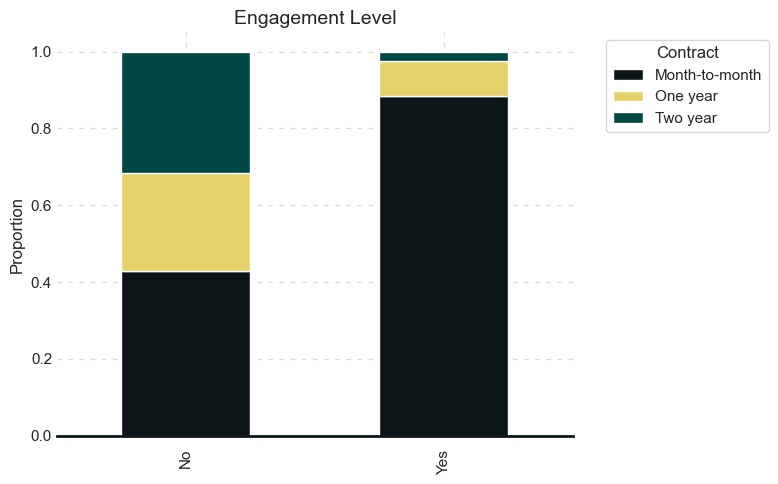

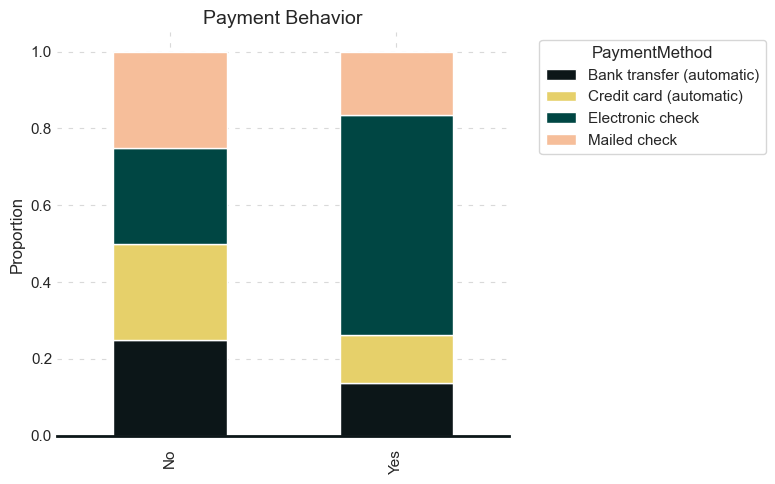

In [15]:
# InternetService, Contract, and PaymentMethod
stacked_bar(
    df,
    target="Churn",
    column="InternetService",
    title="Product Type",
    save_path=FIGURES_DIR / "churn_by_internet_service.png",
)

stacked_bar(
    df,
    target="Churn",
    column="Contract",
    title="Engagement Level",
    save_path=FIGURES_DIR / "churn_by_contract.png",
)

stacked_bar(
    df,
    target="Churn",
    column="PaymentMethod",
    title="Payment Behavior",
    save_path=FIGURES_DIR / "churn_by_payment_method.png",
)

The data seems to indicate a clear distinction between two contrasting customer poles, likely reflecting a generational or lifestyle gap in how services are consumed. While these do not account for every customer, they highlight an interesting divide. On one side, customers with no internet service, long-term contracts or traditional payment methods (like mail-in checks) are underrepresented among churners. This segment appears to view the service as a stable utility, where loyalty is driven by habit and low technological friction. These "traditional" users seem to represent the most stable part of the company’s anchor.

In contrast, churn is very concentrated among customers with fiber optic, month-to-month contracts or electronic billing. This profile would typically correspond to a more tech-savvy and mobile population that prioritizes flexibility. While these are higher-value customers due to their premium services, they also have much lower switching costs and a higher propensity to react to market competition. This suggests that for this "digital" segment, loyalty is not a given but must be actively maintained.

To confirm these profiles, we can isolate customers who combine all these traits and look at their churn level.

In [16]:
# We create a segment to see the correlation between these 'traditional' traits
traditional_profile = df[
    (df['InternetService'] == 'No') & 
    (df['Contract'].isin(['One year', 'Two year'])) & 
    (df['PaymentMethod'].isin(['Mailed check', 'Bank transfer (automatic)']))
]

digital_profile = df[
    (df['InternetService'] == 'Fiber optic') & 
    (df['Contract'] == 'Month-to-month') & 
    (df['PaymentMethod'] == 'Electronic check')
]

print(f"Traditional segment size: {len(traditional_profile)} customers")
print(f"Churn rate in traditional segment: {traditional_profile['Churn'].value_counts(normalize=True).get('Yes', 0):.2%}")

print(f"\nDigital segment size: {len(digital_profile)} customers")
print(f"Churn rate in digital segment: {digital_profile['Churn'].value_counts(normalize=True).get('Yes', 0):.2%}")

Traditional segment size: 677 customers
Churn rate in traditional segment: 1.33%

Digital segment size: 1307 customers
Churn rate in digital segment: 60.37%


The results are quite striking: the "pure" traditional segment (n=677) shows a churn rate of only 1.33% while the "pure" digital segment (n=1307) shows a churn rate of 60.37%.

This gap highlights how heterogeneous churn risk is across the customer base. Since a large share of customers lies between these two extremes, a one-size-fits-all retention strategy is unlikely to be efficient. More broadly, these patterns justify the use of a predictive and interpretable modeling approach: not only to identify customers at risk, but also to understand which types of profiles are most exposed and which retention levers may be relevant.

## Key takeaways

The exploratory analysis points to three main conclusions.

- **Churn is heavily concentrated in the early customer lifecycle**, making the first months a critical period for retention. This suggests that onboarding and early engagement are likely to have a disproportionate impact on customer retention.

- **Commitment is one of the strongest markers of customer stability.** Customers on longer contracts are far less exposed to churn, while month-to-month plans are consistently associated with a much more fragile relationship.

- **Churn is structured around distinct customer profiles rather than isolated variables.** In particular, a more “digital” profile (fiber optic, month-to-month contract, electronic payment behavior) appears substantially more volatile than a more “traditional” and committed customer base.

Overall, this notebook provides the business context for the predictive stage: churn is not randomly distributed across customers, but concentrated in identifiable patterns that a model should be able to capture and prioritize.